In [1]:
import os 
import sys
sys.path.append("../")

import torch
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from vi_rnn.utils import *
from vi_rnn.load_data import * 
from vi_rnn.evaluation import * 
from vi_rnn.saving import load_model

import pickle
import pandas as pd 

from evaluation.calc_stats import * 
from scipy.stats import pearsonr 

import warnings
warnings.filterwarnings("ignore")
torch.set_warn_always(False)

torch.manual_seed(0)
np.random.seed(0)

%matplotlib inline
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.usetex'] = False
import matplotlib.gridspec as gridspec

from vi_rnn.generate import generate
from vi_rnn.inference import filtering_posterior

### Load spikes and neuromodulation signal

In [2]:
data_dir_nk339 = '../data/recordings/nk339_mPFC/' 
config = {
    'data_dir': data_dir_nk339, 
    'model_dir': "../models/all/",
    "stat_dir": "../results/model_evals/",
    'sampling_rate': 30_000, # Hz
    'bin_size': 0.05,
    'fr_threshold': 0.5,
    'threshold_neurons': True,
    'z_score_neuromod': False,
    'min_max_norm_neuromod': True,
    'z_score_neurons': False,
    'center_neurons':False,
    'deconvolve': True,
    'convolve_spikes': False,
    'normalize_neuromod': True,
    'center_neuromod': False,
    'center_data': False,
    'load_physiology': False,
    'shuffle': False,
    'dales_law': False,
    'zero_pad': True,
}

In [3]:
spikes, spike_counts, neuromod_activity, trials_df, cell_types = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_train_start'] = int(data_dur - 0.75 * baseline_dur)

config['baseline_test_end'] = config['baseline_train_start']
config['baseline_train_end'] = int(data_dur)
print(config['baseline_test_end'] - config['baseline_test_start'])
# prepare dataset 
x, s, stim_arr, seq_periods, white_noise_trial_avgs, airpuff_trial_avgs, reward_trial_avgs = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=True)
x_train, s_train, stim_train, _, _, _, _ = prepare_dataset(spike_counts,
                                            neuromod_activity,
                                            trials_df,
                                            config,
                                            test=False)

t_end = 5622
123 neurons removed
length of downsampled signal: 112838
length of original signal: 5641891
False
False
288
11
(5760,) (19950,)
Shape of data samples: (184, 19950), (19950,)
12
(17340,) (35830,)
Shape of data samples: (184, 35830), (35830,)


In [4]:
# normalize neuromodulators 
if config["z_score_neuromod"] == False and config["min_max_norm_neuromod"]:
    train_min = s_train.min()
    train_max = s_train.max()
    s_train = (s_train - train_min) / (train_max - train_min)
    s = (s - train_min) / (train_max - train_min)

In [5]:
print(x_train.shape, stim_train.shape, s_train.shape)

(184, 35830) (9, 35830) (35830,)


In [6]:
stim_train.shape

(9, 35830)

### Load model and make some plots

In [7]:
seed = 80 #6679#5450 #3361
rank =4

neuromodulation= "postsynaptic"

model_config = {
    "dataset": "nk339_mPFC",
    "seed": seed,#,970,,#4107,#8495,#8912,#7366,#7756,#1735,#1387,#6834,#9971,#1594,
    "rank": rank,
    "activation": "relu", 
    "stim": True, 
    "bin_size": 0.05, 
    "dales_law": False  
}


filepath = os.path.join("../models/all/", f'{model_config["dataset"]}_{neuromodulation}_rank_{model_config["rank"]}_activation_{model_config["activation"]}_seed_{model_config["seed"]}_stim_{model_config["stim"]}_binsize_{str(model_config["bin_size"]).replace(".", "_")}_daleslaw_{model_config["dales_law"]}_obs_poisson_shift_0')
vae, params, task_params, training_params = load_model(filepath)


dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'prior_architecture', 'rnn_params', 'causal', 'cell_types'])
184 184
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 0.4
using acausal circular padding


In [8]:
print(x_train.shape, stim_train.shape, s_train.shape)

(184, 35830) (9, 35830) (35830,)


In [9]:
x = torch.from_numpy(x).to(torch.float32) 
x_train = torch.from_numpy(x_train).to(torch.float32)
s = torch.from_numpy(s).to(torch.float32)
s_train = torch.from_numpy(s_train).to(torch.float32)
stim_arr = torch.from_numpy(stim_arr).to(torch.float32) 
stim_train = torch.from_numpy(stim_train).to(torch.float32)
white_noise_trial_avgs = torch.from_numpy(white_noise_trial_avgs).to(torch.float32)
airpuff_trial_avgs = torch.from_numpy(airpuff_trial_avgs).to(torch.float32)
reward_trial_avgs = torch.from_numpy(reward_trial_avgs).to(torch.float32)

In [10]:
training_params['ed_ratio']

0

In [11]:
s_train.max()

tensor(1.)

In [12]:
#with torch.no_grad():
#    vae.rnn.R_z.copy_(torch.ones_like(vae.rnn.R_z)*-100000000)

In [ ]:
dur = 500
u = torch.zeros(1, vae.dim_u, dur)
Z, v, rates, spikes = generate(vae, 
                              x=x_train[:,:dur],
                              u=stim_train[:,:dur].unsqueeze(0),
                              s=s_train[:dur].unsqueeze(0).unsqueeze(0), 
                              dur = dur,
                              k=1, 
                              initial_state="posterior_sample"
  ) 


_, Z_inferred, Z_encoder, _, _, _, _, alphas = filtering_posterior(vae, 
                                                              x_train[:,:dur].unsqueeze(0), 
                                                            s=s_train[:dur].unsqueeze(0).unsqueeze(0), 
                                                            u=stim_train[:,:dur].unsqueeze(0), 
                                                            k=training_params["k"], 
                                                            resample="systematic",
                                                            t_forward=0, 
                                                            ed_ratio=training_params["ed_ratio"], 
                                                            encoder_padding =0)
rates_inferred, samples = vae.rnn.get_observation(z= Z_inferred,
                        v=v, # we use the same data for gen and infer, so okay
                          s=s_train[:dur].unsqueeze(0).unsqueeze(0))

rates_inferred = rates_inferred[:,:,:,:1].mean(axis=-1).detach().numpy() # average over particles
Z_inferred = Z_inferred.mean(axis=-1).detach().numpy()


[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0.28946832 0.53002286 0.29966265 0.37108153]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0.3240402  0.573758   0.3480499  0.46711403]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.

In [14]:
Z_inferred

array([[[ 0.45357144,  0.62112415,  0.54609025, ...,  0.24303755,
          0.4592932 ,  0.5797609 ],
        [-0.384333  , -0.182334  , -0.14527039, ..., -0.21455362,
         -0.12619811, -0.24007195],
        [-0.19247217,  0.00282942,  0.03978336, ..., -0.18805717,
          0.08190218,  0.21297276],
        [-0.08070009, -0.0916477 , -0.19509847, ...,  0.05118483,
         -0.11246573,  0.0180283 ]]], dtype=float32)

In [15]:
torch.mean(alphas)

tensor(0.4008)

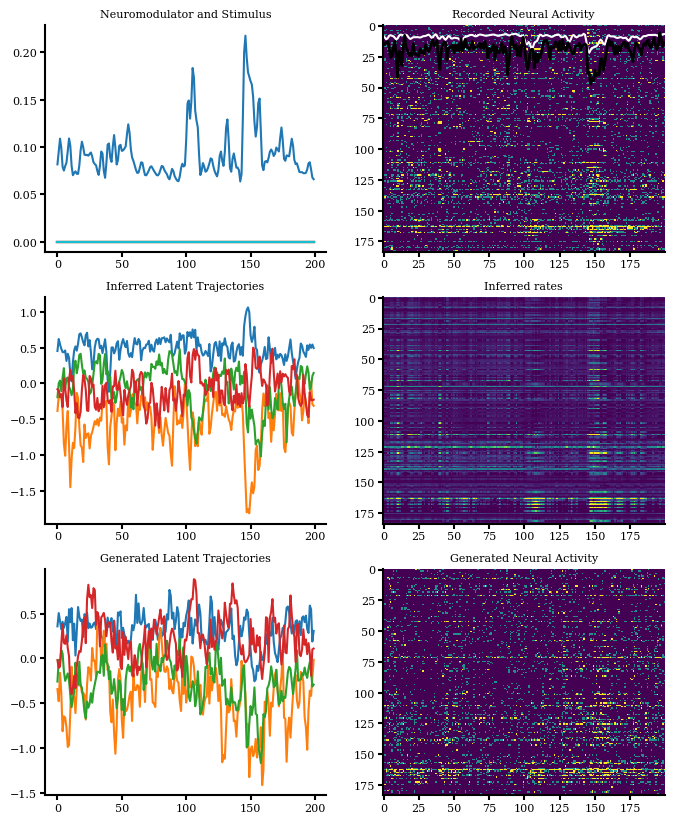

In [16]:
vmax = 2
sample = 0
dur = 200

fig,ax = plt.subplots(3,2, figsize=(8,10))
ax[0,0].plot(s_train[:dur]);
ax[0,0].plot(stim_train[:,:dur].T);
ax[0,1].imshow(x_train[:,:dur], aspect='auto', vmax=vmax);
ax[0,1].plot(s_train[:dur]*100,color='white', alpha=1);
ax[0,1].plot(torch.mean(x_train[:,:dur], axis=0)*100, color='black', linewidth=2);

ax[1,0].plot(Z_inferred[0,:,:dur].T);
ax[1,1].imshow(rates_inferred[0,:,:dur], aspect='auto', vmax=vmax);

ax[2,0].plot(Z[0,:,:dur,sample].T);
ax[2,1].imshow(spikes[0,:,:dur,sample], aspect='auto', vmax=vmax);
ax[1,0].set_title("Inferred Latent Trajectories");
ax[1,1].set_title("Inferred rates");
ax[0,0].set_title("Neuromodulator and Stimulus");
ax[0,1].set_title("Recorded Neural Activity");
ax[2,0].set_title("Generated Latent Trajectories");
ax[2,1].set_title("Generated Neural Activity");

In [17]:
st

NameError: name 'st' is not defined

In [ ]:
def zscore(tensor):
    return (tensor - torch.mean(tensor)) / torch.std(tensor)

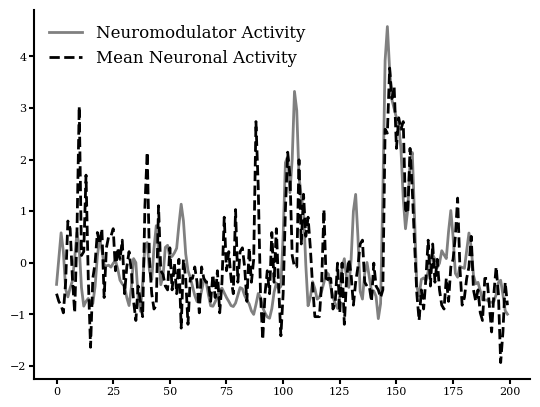

In [ ]:
t0 = 0#np.random.randint(0,4500)
dur = 200
plt.plot(zscore(s_train[t0:t0+dur]), color='grey', alpha=1, linewidth=2, label   ='Neuromodulator Activity');
plt.plot(zscore(torch.mean(x_train[:,t0:t0+dur], axis=0)), color='black', linewidth=2, ls='--', label='Mean Neuronal Activity');
plt.legend(fontsize=12);

In [ ]:
#stim = torch.zeros((0, x_.shape[1]))
stim = stim_arr
trajs = []
num_trajs = 1
t_start, t_end = config['baseline_test_start'], config['baseline_test_start'] + 600

x_, s_ = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size'])
s_ = torch.from_numpy(s_).to(torch.float32)
# normalize neuromodulators 
if config["z_score_neuromod"] == False and config["min_max_norm_neuromod"]:
    s_ = (s_ - train_min) / (train_max - train_min)
   
x_ = torch.from_numpy(x_).to(torch.float32)


In [ ]:
z,v, traj, spikes = generate(vae, x=x_,
                        u=torch.zeros_like(stim.unsqueeze(0)),
                        s=s_.unsqueeze(0).unsqueeze(0), dur = x_.shape[1],k=3, initial_state="posterior_mean");



In [ ]:
dur = 3000

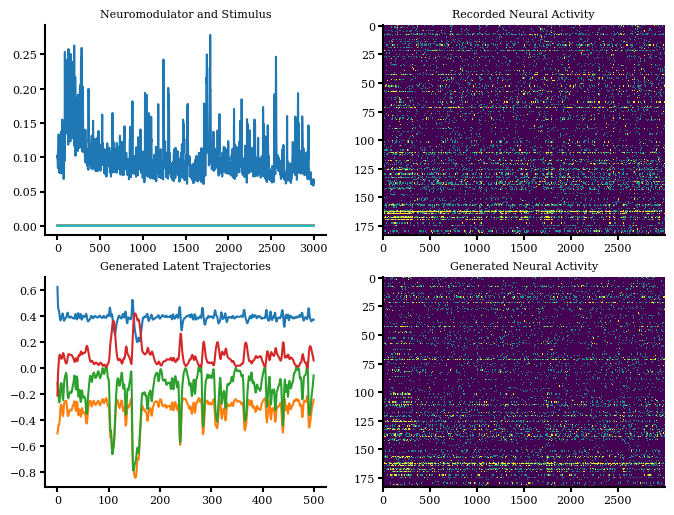

In [ ]:
vmax = 2
fig,ax = plt.subplots(2,2, figsize=(8,6))
ax[0,0].plot((s_)[:dur]);
ax[0,0].plot(stim_train[:,:dur].T);
ax[0,1].imshow(x_[:,:dur], aspect='auto', vmax=vmax);
ax[1,0].plot(Z[0,:,:,0].T);
ax[1,1].imshow(torch.poisson(traj)[0,:,:dur,0], aspect='auto', vmax=vmax);

ax[0,0].set_title("Neuromodulator and Stimulus");
ax[0,1].set_title("Recorded Neural Activity");
ax[1,0].set_title("Generated Latent Trajectories");
ax[1,1].set_title("Generated Neural Activity");

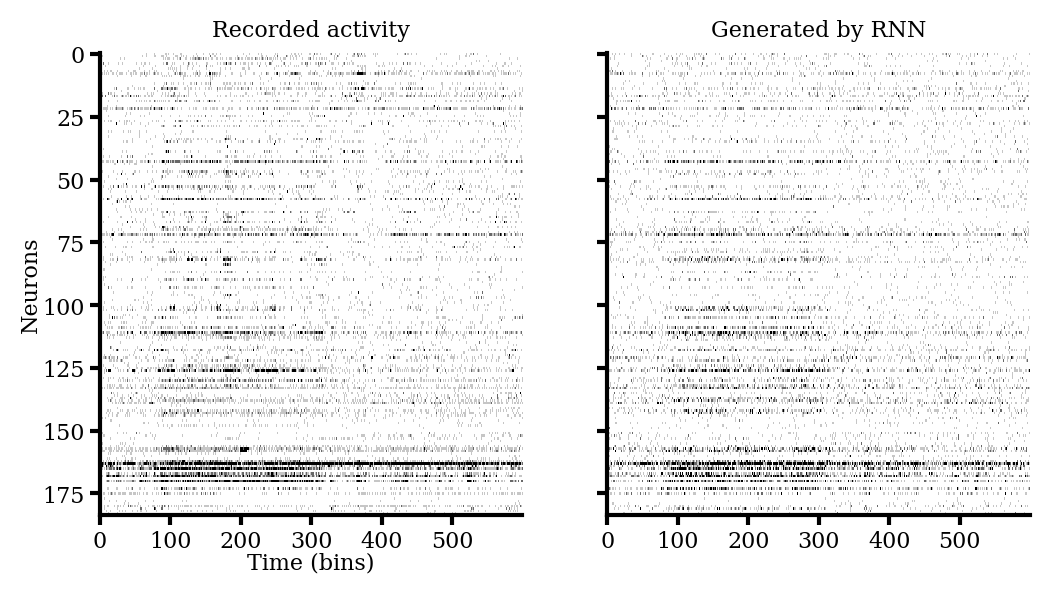

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(6,3),dpi=200,sharey=True,sharex=True)
vmax = 3
ax[1].imshow(np.random.poisson(traj[0,:,:600,0]), vmax=vmax,aspect='auto',cmap = 'Greys');
ax[0].imshow(x_[:,:600], vmax=vmax,aspect='auto',cmap = 'Greys');
ax[0].set_ylabel('Neurons')
ax[0].set_xlabel('Time (bins)')
ax[1].set_title('Generated by RNN')
ax[0].set_title('Recorded activity');
plt.savefig('../figures/generated_activity.png', bbox_inches='tight')

### Compute psth around neuromodulator peaks

In [ ]:
def compute_LC_trig_activity(traj, neuromod_val, dur=200): 
    neuromod_zsc = (neuromod_val - neuromod_val.mean()) / neuromod_val.std() 
    # take everything above 2 standard deviations 
    neuromod_peaks = np.where(neuromod_zsc > 2)[0]
    psths_val = np.zeros((len(neuromod_peaks), traj.shape[0], dur))
    nrpn = np.zeros((len(neuromod_peaks), dur))
    for i, peak in enumerate(neuromod_peaks):
        if peak - dur // 2 >= 0 and peak + dur // 2 < traj.shape[1]:
            psths_val[i] = traj[:, peak - dur // 2:peak + dur // 2]
            nrpn[i] = neuromod_val[peak - dur // 2:peak + dur // 2]
    psths_val = psths_val.mean(axis=0)
    # sort by time of peak
    max_indices = np.argmax(psths_val, axis=1)
    psths_sorted = psths_val[np.argsort(max_indices)]
    psths_sorted = (psths_sorted - psths_sorted.mean(axis=1, keepdims=True)) / psths_sorted.std(axis=1, keepdims=True)
    nrpn = nrpn.mean(axis=0)
    return psths_val, psths_sorted, nrpn, max_indices

In [ ]:
import matplotlib.gridspec as gridspec
def plot_psths(psths_val, ind_test):
    psths_val = np.nan_to_num(psths_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    gs = gridspec.GridSpec(
        1, 3,
        width_ratios=[20, 1, 1],
        wspace=0.05,
        left=0.05, right=0.95, top=0.95, bottom=0.05
    )

    ax_heatmap = plt.subplot(gs[0])
    im = ax_heatmap.imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4, origin='upper', aspect='auto')
    ax_heatmap.set_yticks([])
    #ax.set_yticklabels([])
    ax_heatmap.axis('off')

    ax_cbar = plt.subplot(gs[1])
    plt.colorbar(im, cax=ax_cbar) 
    ax.set_xlabel('Time')
    ax_bar = plt.subplot(gs[2])
    ax_bar.set_ylim(ax_heatmap.get_ylim()) 
    ax_bar.set_xlim(0, 1)
    ax_bar.axis('off')  # Hide the frame and ticks


In [ ]:
def zscore_np(array):
    return (array - np.mean(array)) / np.std(array)

In [ ]:

t_start, t_end = config['baseline_test_start'], config['baseline_test_start'] + 600
# t_start, t_end = 4_750 - 300, 4_750
# t_start, t_end = odor_blocks[-1][0] - 10, odor_blocks[-1][1] + 10
x_, s_ = get_block(spike_counts, neuromod_activity, t_start, t_end - t_start, config['bin_size'])

# normalize neuromodulators 
if config["z_score_neuromod"] == False and config["min_max_norm_neuromod"]:
    s_ = (s_ - train_min) / (train_max - train_min)
   
psths_val, psths_val_zs, nrpn, ind_test = compute_LC_trig_activity(x_, s_, dur=200)
psths_val_zs = np.nan_to_num(psths_val_zs)


In [ ]:
stim = torch.zeros((0,vae.dim_u, x_.shape[1])) 
trajs = []
num_trajs = 5

trajs_gen = []

x_psts = torch.from_numpy(x_).to(torch.float32).unsqueeze(0)
s_psts = torch.from_numpy(s_).to(torch.float32).unsqueeze(0).unsqueeze(0)
u = torch.zeros((1, vae.dim_u, x_psts.shape[2]))
z,v, traj, spikes = generate(vae, x=x_psts,
                        u=u,
                        s=s_psts,k=num_trajs, initial_state="posterior_mean");

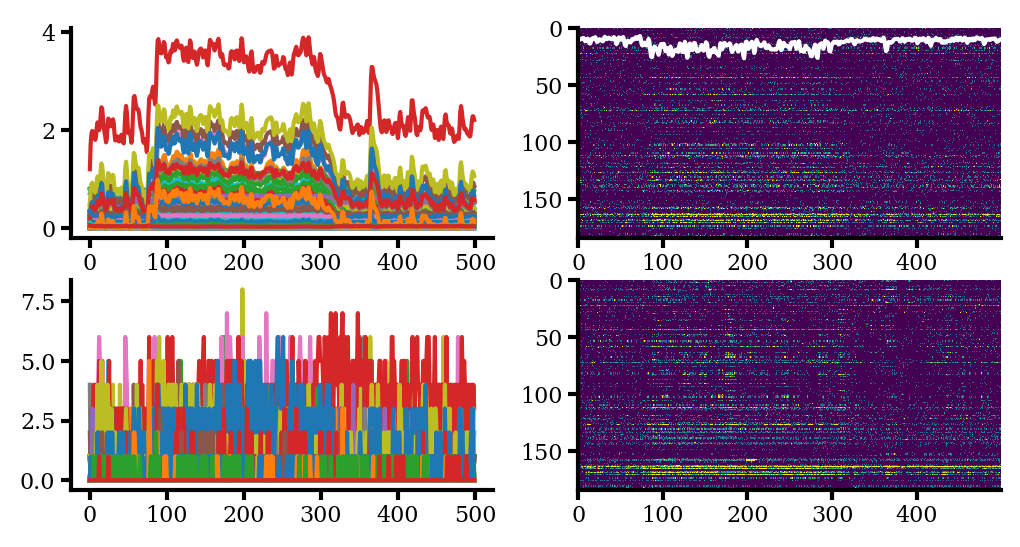

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(6,3),dpi=200)

plt_dur =500

ax[0,0].plot(traj[0,:, :plt_dur, 0].T);
ax[0,1].imshow(spikes[0,:,:plt_dur,0], aspect='auto', vmax=3);
ax[1,0].plot(x_psts[0,:, :plt_dur].T);
ax[1,1].imshow(x_psts[0,:,:plt_dur], aspect='auto', vmax=3);
ax[0,1].plot(s_psts[0,0,:plt_dur]*100, color='white', alpha=1);

In [ ]:
sample_spikes=True

Text(0.5, 1.0, 'Generated by RNN')

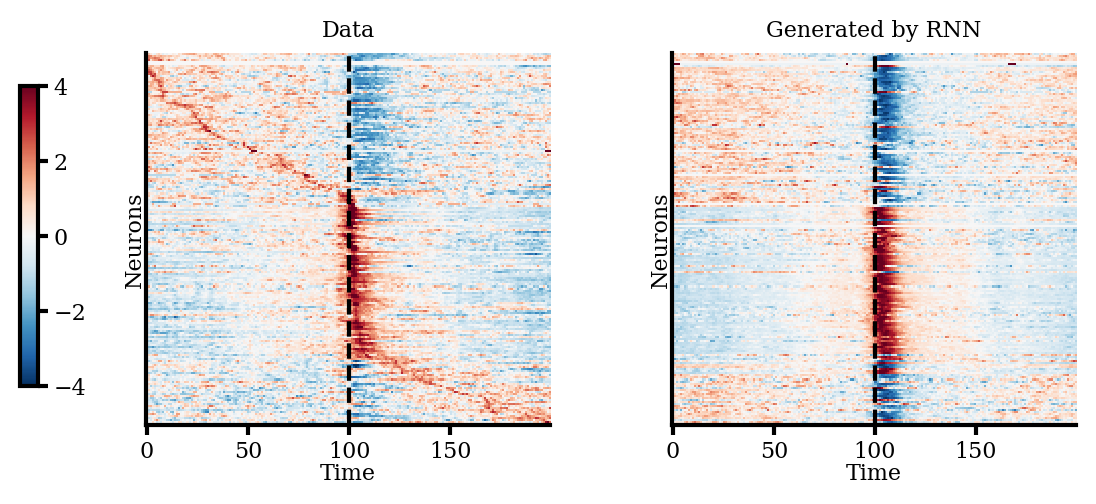

In [ ]:
random_sort_inds = np.random.permutation(psths_val.shape[0])
random_sort_inds = np.arange(psths_val.shape[0])
fig = plt.figure(figsize=(6,3),dpi=200)
gs = gridspec.GridSpec(1,2, wspace=0.3)

ax = [fig.add_subplot(gs[0, i]) for i in range(2)]
mappable = ax[0].imshow(psths_val_zs[random_sort_inds], cmap='RdBu_r', vmin=-4, vmax=4)
ax[0].set_yticks([])
ax[0].set_yticklabels([])
ax[0].set_ylabel('Neurons')
ax[0].set_xlabel('Time')
ax[0].set_title('Data')

i = 1
if sample_spikes:
    avg_traj = torch.poisson(traj).mean(dim=(0,3))
else:
    avg_traj = traj.mean(dim=(0,3))
psth_vals, psths, nrpn, ind_1 = compute_LC_trig_activity(avg_traj, s_, dur=200)




psths_resorted = psth_vals[np.argsort(ind_test)]
# psths_resorted = psth_vals

psths_resorted_zs = (psths_resorted - psths_resorted.mean(axis=1, keepdims=True)) / psths_resorted.std(axis=1, keepdims=True)
psths_resorted_zs = np.nan_to_num(psths_resorted_zs)

mappable2 = ax[i].imshow(psths_resorted_zs[random_sort_inds], cmap='RdBu_r', vmin=-4, vmax=4)

ax[i].set_yticks([])
ax[i].set_yticklabels([])
ax[i].set_ylabel('Neurons')
ax[i].set_xlabel('Time')
#ax[i].set_box_aspect(1)
# fig.colorbar(mappable1, label='intensity', shrink=0.5)
#ax[i].set_title(model)
# break
i += 1
plt.tight_layout()
cbar_ax = fig.add_axes([0.02, 0.25, 0.015, 0.5])  
# fig.savefig('../../results/figures/psth_neuromod_peaks.png')
fig.colorbar(mappable, cax=cbar_ax)

ax[0].axvline(100, color='black', linestyle='--')
ax[1].axvline(100, color='black', linestyle='--')
ax[1].set_title('Generated by RNN')

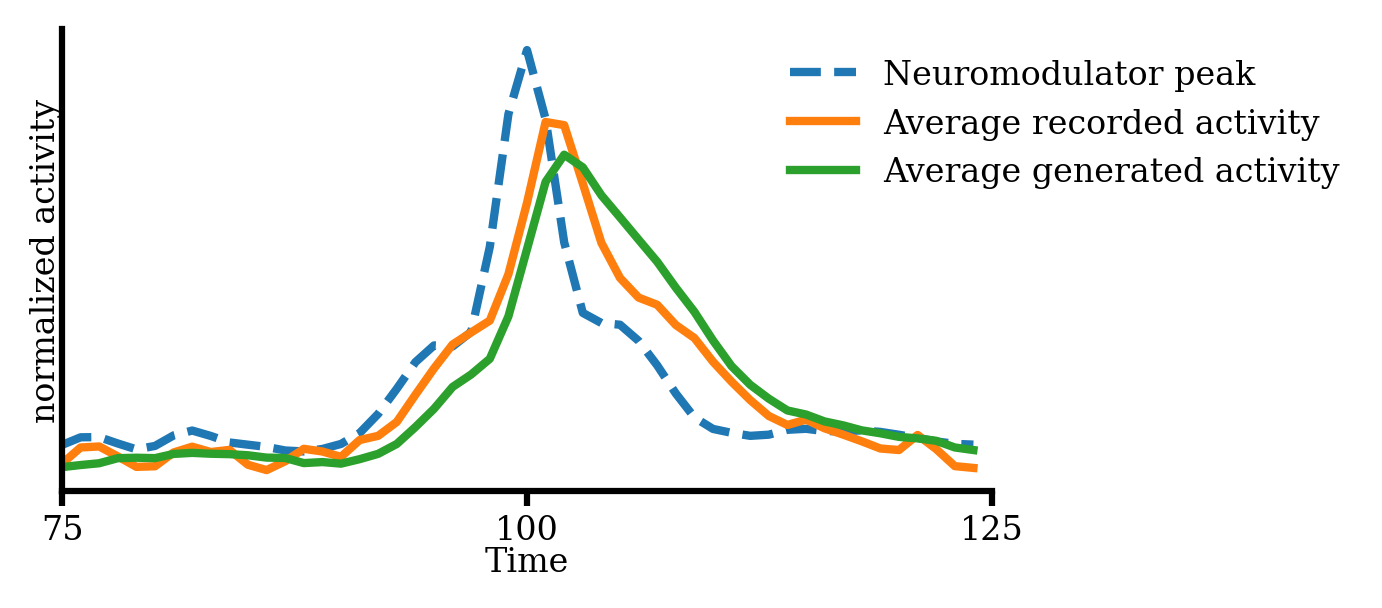

In [ ]:
def zscore_np(array):
    return (array - np.mean(array)) / np.std(array)

fig, ax = plt.subplots(figsize=(4,2),dpi=300)
t1 = 75
t2 = 125
ax.plot(zscore_np(nrpn[t1:t2]), linewidth=2, label = 'Neuromodulator peak', ls ='--')
ax.plot(zscore_np(((psths_val)).mean(axis=0)[t1:t2]), linewidth=2,label = 'Average recorded activity')
ax.plot(zscore_np(((psths_resorted)).mean(axis=0)[t1:t2]), linewidth=2, label='Average generated activity')
for spine in ax.spines.values():
    spine.set_visible(True)
ax.set_ylabel("normalized activity")
ax.legend(bbox_to_anchor=(.75, 1), loc='upper left', fontsize=8)
ax.set_yticks([])
ax.set_xlabel('Time')
ax.set_xticks([0, 25, 50])
ax.set_xticklabels([75,100,125])
ax.set_xlim(0, t2 - t1)
ax.spines[['top', 'right']].set_visible(False)
# fig.savefig('../../results/figures/nrpn.svg', format='svg')

### Visualize trajectories of inhibitory neurons

In [ ]:
def plot_traces(trajs_gen, trajs_test, neurons=None):
    neurons = [132, 10, 20, 55, 84]
    colors = ['#000000', "#a913d6",  "#008080", "#c98510", "#c9081b"]
    num_neurons = len(neurons)

    fig, ax = plt.subplots(num_neurons, figsize=(15, 10))

    # neurons = np.arange(-1, -10, -1)
    for i, neuron in enumerate(neurons): #, [32, 10, 133, 17, 78]

            ax[i].plot(trajs_gen[neuron].detach(), linewidth=3, label='Gen', alpha=1.0)
            ax[i].plot(trajs_test[neuron].detach(), linewidth=3, label='Gen', alpha=1.0)

            for spine in ax[i].spines.values():
                spine.set_visible(False)
            
    plt.tight_layout()


In [ ]:
trial_block = [5, 8] # airpuff trials
trial_trajs_gen = {}
num_trajs = 2
with torch.no_grad():

  trajs = [generate(vae=vae, 
                x = x[:, seq_periods[j][0]:seq_periods[j][1]].unsqueeze(0),
                s = s[seq_periods[j][0]:seq_periods[j][1]].unsqueeze(0).unsqueeze(0),
                u = stim_arr[:, seq_periods[j][0]:seq_periods[j][1]].unsqueeze(0),
                initial_state = "posterior_sample", 
                k = num_trajs,
                )[2] for j in range(trial_block[0], trial_block[1])]
    
trajs = torch.stack(trajs).squeeze(1)  # shape: (num_blocks, num_neurons, dur, num_trials)

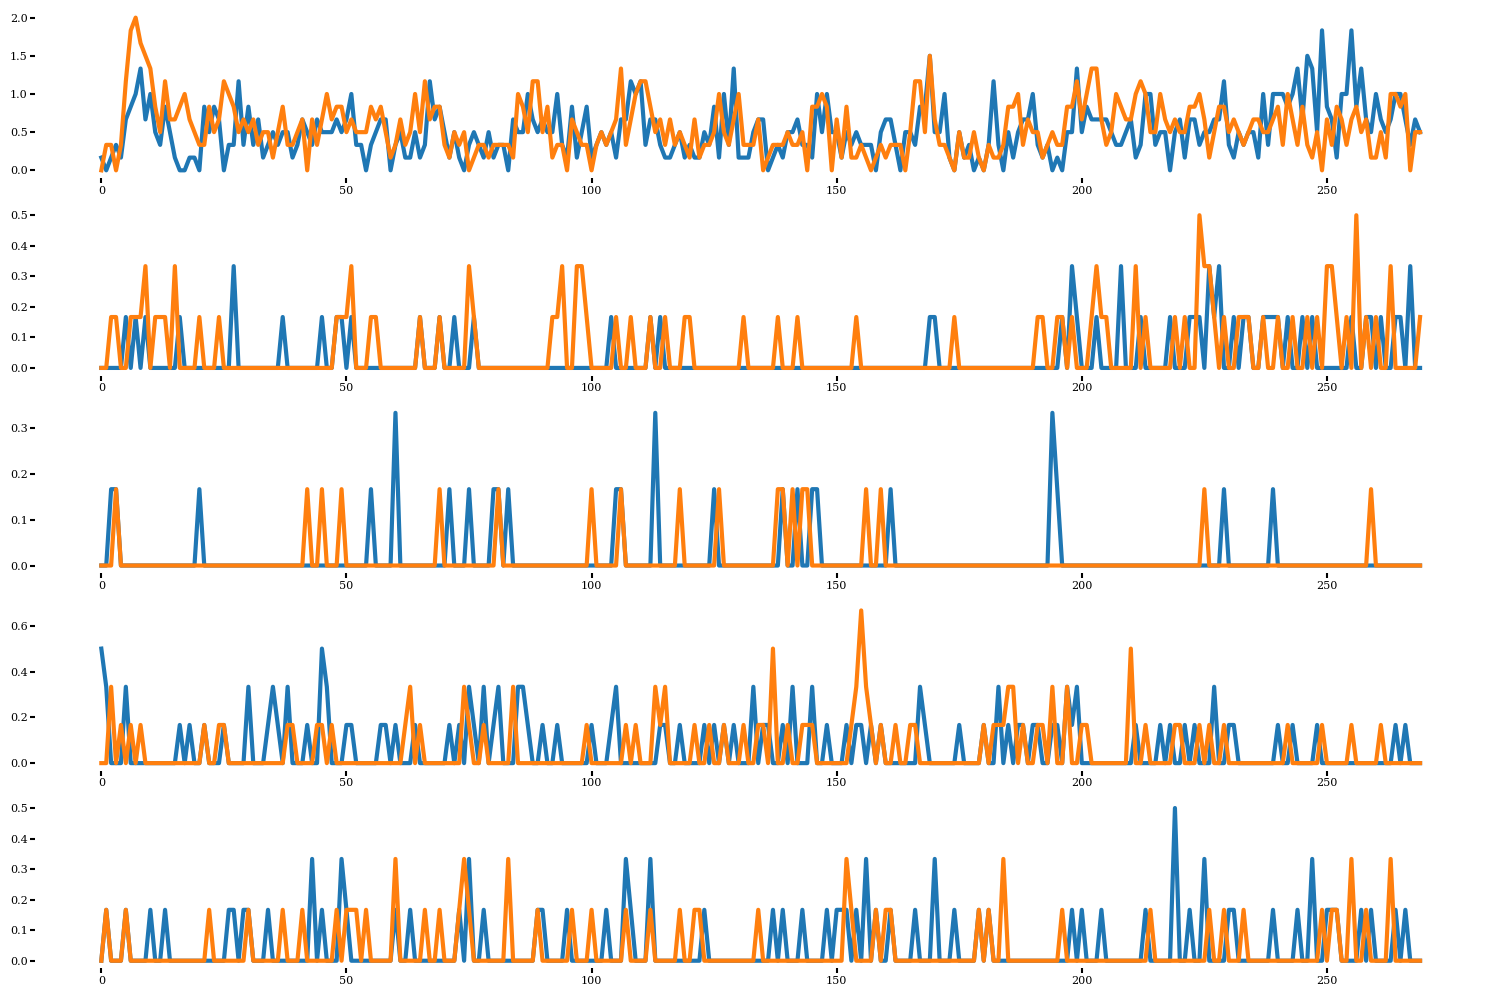

In [ ]:
plot_traces(torch.poisson(trajs).mean(dim=(0,3)), airpuff_trial_avgs)

In [ ]:
from evaluation.eval_spikestats import eval_spikestats, eval_pairwise_corr

In [ ]:
device = vae.rnn.transition.m.device

In [ ]:
x_test_baseline = training_params["x_test_baseline"].to(device=device)
s_test_baseline = training_params["s_test_baseline"].to(device=device).view(1, 1, -1)
stim_arr_test_baseline = training_params["stim_arr_test_baseline"].to(device=device).unsqueeze(0)
num_samples = 2500


In [ ]:
x_test_baseline.shape

torch.Size([184, 5760])

In [ ]:
data_dict_data,data_raw_data= eval_spikestats(
                            x_test=x_test_baseline[:, :2700].unsqueeze(0).repeat(2,1,1),
                            x_gen = x_test_baseline[:, -2700:].unsqueeze(0).repeat(2,1,1),
                            verbose=True,
                            num_samples=num_samples,
                            min_data_points_isi = 5, 
                            return_raw_data=True, 
                            dt=0.05, 
                            smooth_spikes_KL=True, 
                            smooth_sigma_KL=5,
                            pse_smooth=20, 
                            pse_freq_cutoff=200)

ignoring 5 units for ISI baseline calculation
Removing 4 constant-variance neurons out of 184 total.
R^2 of pairwise correlations: 0.640
n outliers: 0
Evaluation results:
---------------
mean_rate 0.9826455371175811
mean_ISI 0.9241052815273207
std_ISI 0.8079644053740362
r2_pwcorr 0.6403400593778452
KL_data 0.415415206816877
power_spectr_distance 0.060785945143263395
---------------


In [ ]:
data_dict,data_raw = eval_spikestats(
                            x_test=x_test_baseline,
                            vae=vae,
                            s_test=s_test_baseline,
                            u_test=stim_arr_test_baseline, 
                            initial_state="posterior_sample",
                            verbose=True,
                            num_samples=num_samples,
                            min_data_points_isi = 5, 
                            return_raw_data=True, 
                            dt=0.05, 
                            smooth_spikes_KL=True, 
                            smooth_sigma_KL=5,
                            pse_smooth=20, 
                            pse_freq_cutoff=200)

Generating data from VAE for evaluation...
ignoring 7 units for ISI baseline calculation
Removing 7 constant-variance neurons out of 184 total.
R^2 of pairwise correlations: 0.338
n outliers: 0
Evaluation results:
---------------
mean_rate 0.9634457493941662
mean_ISI 0.6954592651358608
std_ISI 0.6347053548548919
r2_pwcorr 0.33819834165353413
KL_data 0.5742249595776894
power_spectr_distance 0.09782350645285912
---------------


In [ ]:
data_raw.keys()

dict_keys(['mean_rate', 'mean_ISI', 'std_ISI', 'pwcorr', 'KL_data', 'power_spectr_distance'])

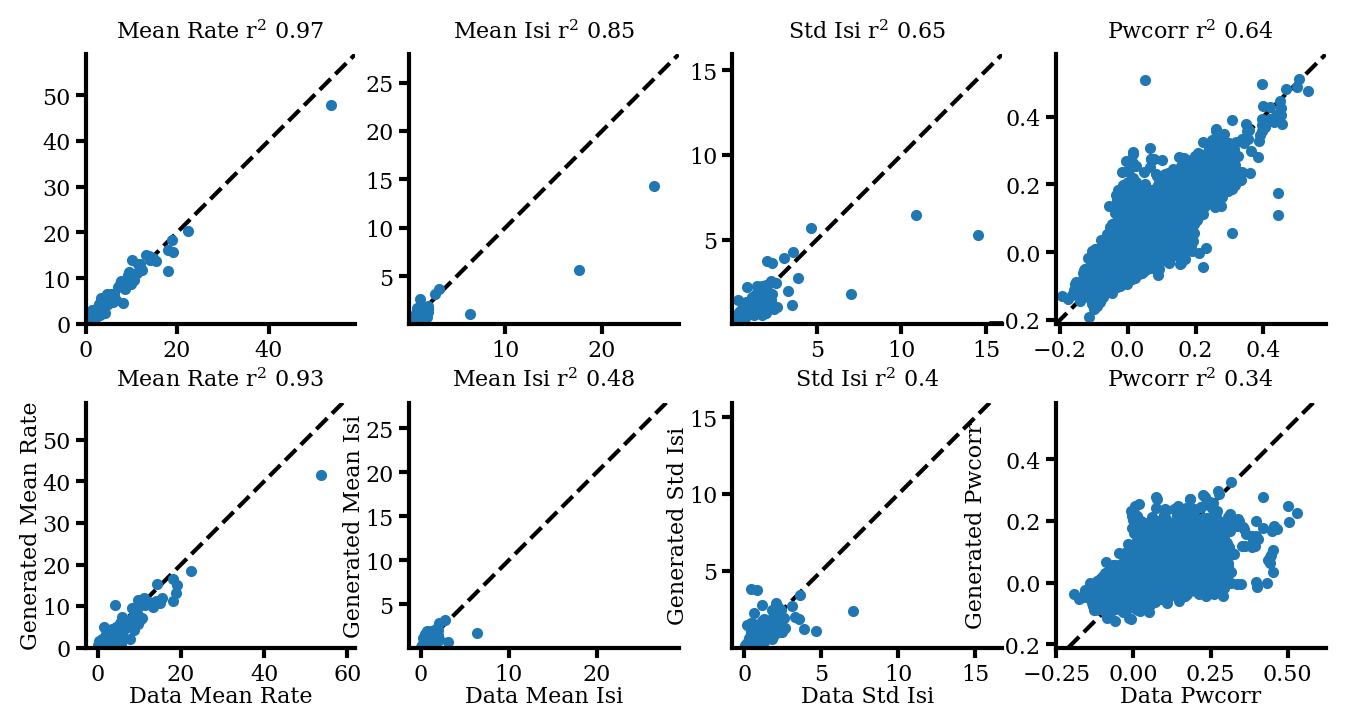

In [ ]:
titles = ["mean_rate", "mean_ISI", "std_ISI", "pwcorr"]
fig, ax = plt.subplots(2,4, figsize=(8,4), dpi=200, sharex=False, sharey="col")
for i, stat in enumerate(titles):

    ax[0,i].scatter(data_raw_data[stat][0][0], data_raw_data[stat][0][1])
    ax[1,i].set_xlabel("Data " + stat.replace("_", " ").title())
    #ax[1,i].set_ylabel("Generated " + stat.replace("_", " ").title())
    ax[0,i].set_title(stat.replace("_", " ").title() + r" $r^2$ " + str(np.round(pearsonr(data_raw_data[stat][0][0], data_raw_data[stat][0][1])[0]**2,2)))
    ax[1,i].set_title(stat.replace("_", " ").title() + r" $r^2$ " + str(np.round(pearsonr(data_raw[stat][0][0], data_raw[stat][0][1])[0]**2,2)))
    max_val = max(max(data_raw_data[stat][0][0]), max(data_raw_data[stat][0][1]))
    max_val_gen = max(max(data_raw[stat][0][0]), max(data_raw[stat][0][1]))
    max_val = max(max_val, max_val_gen)
    min_val = min(min(data_raw_data[stat][0][0]), min(data_raw_data[stat][0][1]))
    min_val_gen = min(min(data_raw[stat][0][0]), min(data_raw[stat][0][1]))
    min_val = min(min_val, min_val_gen)

    ax[0,i].set_xlim(min_val*1.1, max_val*1.1)
    ax[0,i].set_ylim(min_val*1.1, max_val*1.1)
    ax[0,i].plot([min_val*1.1, max_val*1.1], [min_val*1.1, max_val*1.1], color='black', ls='--', zorder= -10)
    ax[0,i].set_aspect('equal', adjustable='box')

    ax[1,i].scatter(data_raw[stat][0][0], data_raw[stat][0][1])
    ax[1,i].set_xlabel("Data " + stat.replace("_", " ").title())
    ax[1,i].set_ylabel("Generated " + stat.replace("_", " ").title())
    ax[1,i].plot([min_val*1.1, max_val*1.1], [min_val*1.1, max_val*1.1], color='black', ls='--', zorder= -10)
    ax[1,i].set_aspect('equal', adjustable='box')


    max_rate = max(max(data_raw["mean_rate"][0][0]), max(data_raw["mean_rate"][0][1]))

    ax[0,i].set_aspect('equal', adjustable='box')
    ax[1,i].set_aspect('equal', adjustable='box')
